# Phase 2: Data Validation & Experiment Integrity Audit
**Project:** Marketing Campaign A/B Test and Conversion Funnel Analysis  
**Audience:** Hiring Managers, Data & Analytics Leadership  

---
### Objective
Before conducting hypothesis testing or measuring campaign lift, an experiment must undergo rigorous data hygiene and integrity verification. This notebook audits:
1. **Data Completeness & Nulls**: Ensuring zero client-side tracking dropouts.
2. **Identifier Uniqueness & Unit of Diversion**: Verifying the Independent & Identically Distributed (I.I.D.) assumption.
3. **Sample Ratio Mismatch (SRM)**: Goodness-of-fit testing against the planned 96:4 split to ensure traffic routing was uncompromised.
4. **Ad Exposure Distribution & Outlier Detection**: Auditing `total_ads` skew and identifying the critical *time-on-platform confound*.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Dependencies loaded successfully.")


Dependencies loaded successfully.


## 1. Data Ingestion
Loading dataset from raw storage and reviewing the schema.

In [2]:
# Resolve path whether run from root or notebooks/ directory
csv_path = os.path.join("..", "data", "raw", "marketing_AB.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join("data", "raw", "marketing_AB.csv")

df = pd.read_csv(csv_path)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")
df.head()


Total Rows: 588,101
Total Columns: 6


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


## 2. Check 1: Missing / Null Values Audit
### Business Rationale
Missing values in ad tracking often signify client-side tracking failures (e.g., ad blockers preventing pixel firing, dropped conversion webhooks). If dropouts happen selectively, it biases the conversion rate.

In [3]:
null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts)
assert null_counts.sum() == 0, "Error: Unexpected missing values found!"
print("\n-> Check 1 Status: VERIFIED (100% data completeness)")


Missing values per column:
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

-> Check 1 Status: VERIFIED (100% data completeness)


## 3. Check 2: Identifier Uniqueness (Unit of Diversion)
### Business Rationale
A valid A/B test requires the **unit of randomization** to match the **unit of analysis**. If the same user appears multiple times, the Independent and Identically Distributed (I.I.D.) assumption is violated, underestimating standard errors and inflating false positives ($p$-hacking).

In [4]:
total_rows = len(df)
unique_users = df['user_id'].nunique()
duplicate_count = df['user_id'].duplicated().sum()

print(f"Total Observations:    {total_rows:,}")
print(f"Unique User IDs:       {unique_users:,}")
print(f"Duplicate Identifiers: {duplicate_count:,}")

assert duplicate_count == 0, "Error: Duplicate user IDs detected!"
print("\n-> Check 2 Status: VERIFIED (Each row represents a distinct, unique user)")


Total Observations:    588,101
Unique User IDs:       588,101
Duplicate Identifiers: 0

-> Check 2 Status: VERIFIED (Each row represents a distinct, unique user)


## 4. Check 3: Sample Ratio Mismatch (SRM) & Allocation Imbalance
### Business Rationale
**What is SRM?** When the observed traffic ratio significantly deviates from the planned assignment ratio, it indicates a technical flaw (e.g. ad delivery errors, browser crashes, or dropouts affecting one variant).  

**Why 96:4 instead of 50:50?** In commercial advertising, the control group is served a Public Service Announcement (PSA) which generates zero revenue. Setting aside 50% of 588,000 visitors would incur massive opportunity loss. A 4% control group (23,524 users) provides plenty of statistical power while keeping 96% commercial monetization. We test against the planned 96:4 split using a Chi-Square goodness-of-fit test.

In [5]:
n_ad = (df['test_group'] == 'ad').sum()
n_psa = (df['test_group'] == 'psa').sum()

prop_ad = n_ad / total_rows
prop_psa = n_psa / total_rows

print(f"Treatment ('ad'):  {n_ad:,} ({prop_ad:.4%})")
print(f"Control   ('psa'): {n_psa:,} ({prop_psa:.4%})")
print(f"Ratio:             {n_ad / n_psa:.4f} : 1")

# Chi-Square test vs expected 96:4
exp_ad = total_rows * 0.96
exp_psa = total_rows * 0.04
chi2_stat, p_val = stats.chisquare([n_ad, n_psa], [exp_ad, exp_psa])

print(f"\nChi-Square Statistic: {chi2_stat:.6f}")
print(f"p-value:              {p_val:.6f}")

if p_val > 0.01:
    print("-> Check 3 Status: CONSISTENT (Matches assumed 96:4 design; p > 0.01)")
else:
    print("-> Check 3 Status: FAILED (Sample Ratio Mismatch detected)")


Treatment ('ad'):  564,577 (96.0000%)
Control   ('psa'): 23,524 (4.0000%)
Ratio:             24.0000 : 1

Chi-Square Statistic: 0.000000
p-value:              0.999788
-> Check 3 Status: CONSISTENT (Matches assumed 96:4 design; p > 0.01)


## 5. Check 4: Ad Exposure Distribution & Outlier Detection
### Business Rationale & The Exposure Confound
Ad impressions (`total_ads`) are heavily skewed. Furthermore, analysts must be wary of the **reverse causality / engagement confound**:
- Highly engaged users browse more pages, stay longer, accumulate more impressions, and naturally convert at higher rates.
- Disengaged users bounce immediately (seeing 1–3 ads) and rarely convert.
Let's inspect the distribution and define the standard 1.5 × IQR outlier boundary.

In [6]:
q25 = df['total_ads'].quantile(0.25)
median = df['total_ads'].median()
q75 = df['total_ads'].quantile(0.75)
iqr = q75 - q25
upper_bound = q75 + 1.5 * iqr

print(f"Ad Exposure Summary:")
print(f"  - Min:                  {df['total_ads'].min()}")
print(f"  - 25th Percentile (Q1): {q25:.1f}")
print(f"  - 50th Percentile (Med):{median:.1f}")
print(f"  - 75th Percentile (Q3): {q75:.1f}")
print(f"  - 95th Percentile:      {df['total_ads'].quantile(0.95):.1f}")
print(f"  - Max Exposure:         {df['total_ads'].max()}")
print(f"  - 1.5*IQR Upper Bound:  {upper_bound:.1f} ads")

outliers = df[df['total_ads'] > upper_bound]
print(f"\nOutlier Count (> {upper_bound:.1f} ads): {len(outliers):,} ({len(outliers)/total_rows:.2%})")

cr_normal = df[df['total_ads'] <= upper_bound]['converted'].mean()
cr_outliers = outliers['converted'].mean()

print(f"Conversion Rate among normal users (<= {upper_bound:.1f} ads): {cr_normal:.4%}")
print(f"Conversion Rate among outlier users (> {upper_bound:.1f} ads):   {cr_outliers:.4%}")


Ad Exposure Summary:


  - Min:                  1
  - 25th Percentile (Q1): 4.0
  - 50th Percentile (Med):13.0
  - 75th Percentile (Q3): 27.0
  - 95th Percentile:      88.0
  - Max Exposure:         2065
  - 1.5*IQR Upper Bound:  61.5 ads

Outlier Count (> 61.5 ads): 52,057 (8.85%)
Conversion Rate among normal users (<= 61.5 ads): 1.3273%
Conversion Rate among outlier users (> 61.5 ads):   14.8453%


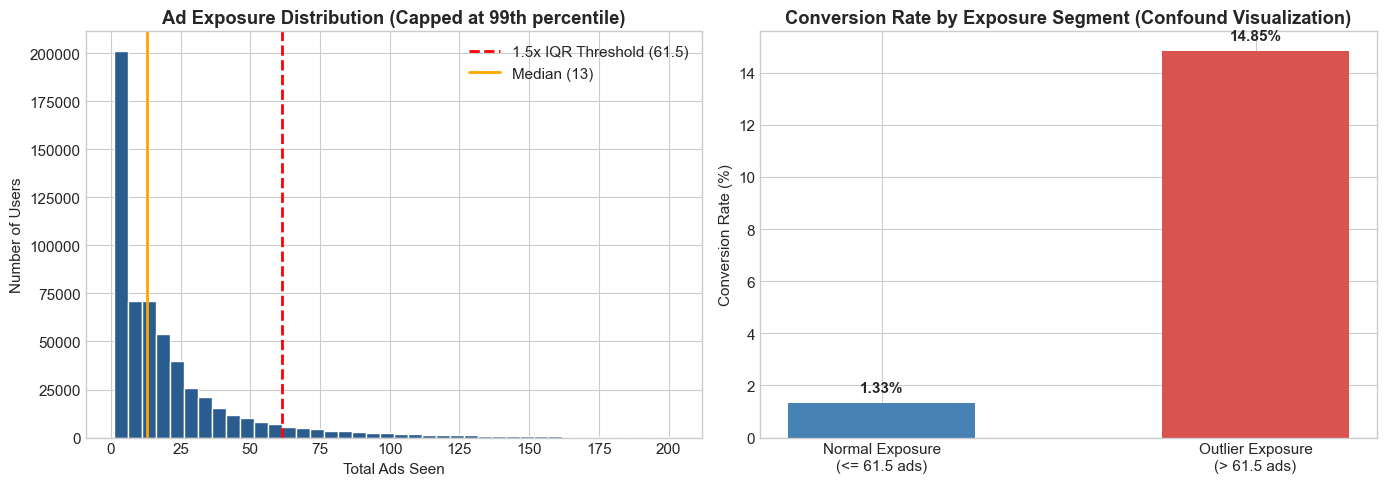

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram up to 99th percentile
p99 = df['total_ads'].quantile(0.99)
axes[0].hist(df[df['total_ads'] <= p99]['total_ads'], bins=40, color='#2b5c8f', edgecolor='white')
axes[0].axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'1.5x IQR Threshold ({upper_bound:.1f})')
axes[0].axvline(median, color='orange', linestyle='-', linewidth=2, label=f'Median ({median:.0f})')
axes[0].set_title('Ad Exposure Distribution (Capped at 99th percentile)', fontweight='bold')
axes[0].set_xlabel('Total Ads Seen')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# Plot 2: Conversion Rate: Normal vs Outlier
categories = [f'Normal Exposure\n(<= {upper_bound:.1f} ads)', f'Outlier Exposure\n(> {upper_bound:.1f} ads)']
cr_values = [cr_normal * 100, cr_outliers * 100]
bars = axes[1].bar(categories, cr_values, color=['#4682b4', '#d9534f'], width=0.5)
axes[1].set_title('Conversion Rate by Exposure Segment (Confound Visualization)', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Audit Conclusion & Next Steps
- **Data Hygiene**: The dataset is complete, uncorrupted, and has 0 duplicates or missing values.
- **Sample Allocation Audit**: The sample matches the assumed 96:4 ratio under a Chi-Square test (p = 0.9998), consistent with the assumed design ratio (though not proving proper randomization).
- **Analytical Caution**: Because higher ad exposure strongly correlates with higher conversion rate (1.33% vs 14.85%), subsequent phases will segment exposure into discrete buckets to analyze true marginal lift and avoid confusing user engagement with advertising causation.

**Status:** Ready to proceed to **Phase 3: SQL Exploratory Analysis**.
